**Install & Import Libraries**

In [1]:
!pip install textblob wordcloud

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

from wordcloud import WordCloud

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


True

**Load Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
df = pd.read_csv('/content/drive/MyDrive/flightexperience/KaggleLinks. Flight experience N3700.csv')
df.head()

,id,OverallRating,ReviewHeader,Datetime,VerifiedReview,ReviewBody,TypeOfTraveller,SeatType,Route,DateFlown,SeatComfort,CabinStaffService,GroundService,ValueForMoney,Recommended,Aircraft,FoodBeverages,InflightEntertainment,WifiConnectivity
0,0,1.0,"""Service level far worse then Ryanair""",19th November 2023,True,4 Hours before takeoff we received a Mail stat...,Couple Leisure,Economy Class,London to Stuttgart,Nov-23,1.0,1.0,1.0,1.0,no,NaN,NaN,NaN,NaN
1,1,3.0,"""do not upgrade members based on status""",19th November 2023,True,I recently had a delay on British Airways from...,Business,Economy Class,Brussels to London,Nov-23,2.0,3.0,1.0,2.0,no,A320,1.0,2.0,2.0
2,2,8.0,"""Flight was smooth and quick""",16th November 2023,False,"Boarded on time, but it took ages to get to th...",Couple Leisure,Business Class,London Heathrow to Dublin,Nov-23,3.0,3.0,4.0,3.0,yes,A320,4.0,NaN,NaN
3,3,1.0,"""Absolutely hopeless airline""",16th November 2023,True,"5 days before the flight, we were advised by B...",Couple Leisure,Economy Class,London to Dublin,Dec-22,3.0,3.0,1.0,1.0,no,NaN,NaN,NaN,NaN
4,4,1.0,"""Customer Service is non existent""",14th November 2023,False,"We traveled to Lisbon for our dream vacation, ...",Couple Leisure,Economy Class,London to Lisbon,Nov-23,1.0,1.0,1.0,1.0,no,NaN,1.0,1.0,1.0


**Explore Data**

In [5]:
df.info()
df.describe()

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3701 entries, 0 to 3700
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     3701 non-null   int64  
 1   OverallRating          3696 non-null   float64
 2   ReviewHeader           3701 non-null   object 
 3   Datetime               3701 non-null   object 
 4   VerifiedReview         3701 non-null   bool   
 5   ReviewBody             3701 non-null   object 
 6   TypeOfTraveller        2930 non-null   object 
 7   SeatType               3699 non-null   object 
 8   Route                  2926 non-null   object 
 9   DateFlown              2923 non-null   object 
 10  SeatComfort            3585 non-null   float64
 11  CabinStaffService      3574 non-null   float64
 12  GroundService          2855 non-null   float64
 13  ValueForMoney          3700 non-null   float64
 14  Recommended            3701 non-null   object 
 15  Airc

Index(['id', 'OverallRating', 'ReviewHeader', 'Datetime', 'VerifiedReview',
       'ReviewBody', 'TypeOfTraveller', 'SeatType', 'Route', 'DateFlown',
       'SeatComfort', 'CabinStaffService', 'GroundService', 'ValueForMoney',
       'Recommended', 'Aircraft', 'FoodBeverages', 'InflightEntertainment',
       'WifiConnectivity'],
      dtype='object')

**Data Cleaning**

In [6]:
# Check missing values
df.isnull().sum()

# Drop missing values
df = df.dropna(subset=['ReviewBody'])

# Remove duplicates
df = df.drop_duplicates()

df.shape

(3701, 19)

**Select Text Column**

In [7]:
text_column = 'ReviewBody'

**TextBlob Sentiment**

In [8]:
def textblob_sentiment(text):
    polarity = TextBlob(str(text)).sentiment.polarity
    if polarity > 0:
        return 'Positive'
    elif polarity == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['TextBlob_Sentiment'] = df[text_column].apply(textblob_sentiment)

**VADER Sentiment**

In [9]:
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    score = sia.polarity_scores(str(text))['compound']
    if score > 0:
        return 'Positive'
    elif score == 0:
        return 'Neutral'
    else:
        return 'Negative'

df['VADER_Sentiment'] = df[text_column].apply(vader_sentiment)

**Sentiment Distribution Graphs**

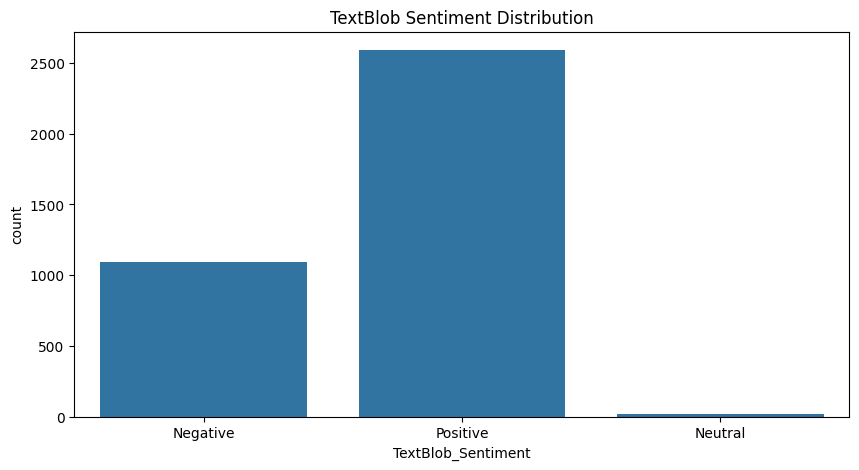

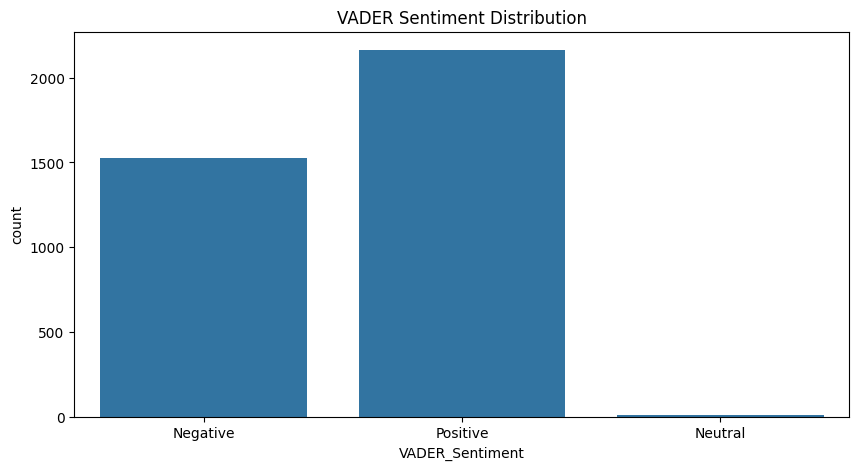

In [10]:
plt.figure(figsize=(10,5))
sns.countplot(x='TextBlob_Sentiment', data=df)
plt.title("TextBlob Sentiment Distribution")
plt.show()

plt.figure(figsize=(10,5))
sns.countplot(x='VADER_Sentiment', data=df)
plt.title("VADER Sentiment Distribution")
plt.show()

**WordCloud**

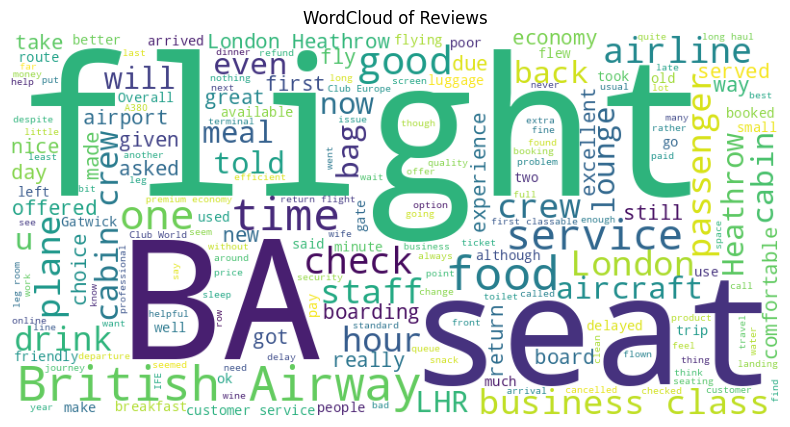

In [11]:
text = " ".join(df[text_column].astype(str))

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud of Reviews")
plt.show()

**Feature Engineering (TF-IDF)**

In [70]:
vectorizer = TfidfVectorizer(max_features=10000)
X = vectorizer.fit_transform(df[text_column])

y = df['TextBlob_Sentiment']

**Train/Test Split**

In [71]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Logistic Regression**

In [72]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

**KNN Model**

In [73]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

**Evaluation**

Logistic Regression Accuracy: 0.8137651821862348
              precision    recall  f1-score   support

    Negative       0.66      0.85      0.74       233
     Neutral       0.00      0.00      0.00         1
    Positive       0.92      0.80      0.86       507

    accuracy                           0.81       741
   macro avg       0.53      0.55      0.53       741
weighted avg       0.84      0.81      0.82       741

KNN Accuracy: 0.7246963562753036
              precision    recall  f1-score   support

    Negative       0.62      0.34      0.44       233
     Neutral       0.00      0.00      0.00         1
    Positive       0.75      0.90      0.82       507

    accuracy                           0.72       741
   macro avg       0.45      0.41      0.42       741
weighted avg       0.71      0.72      0.70       741



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

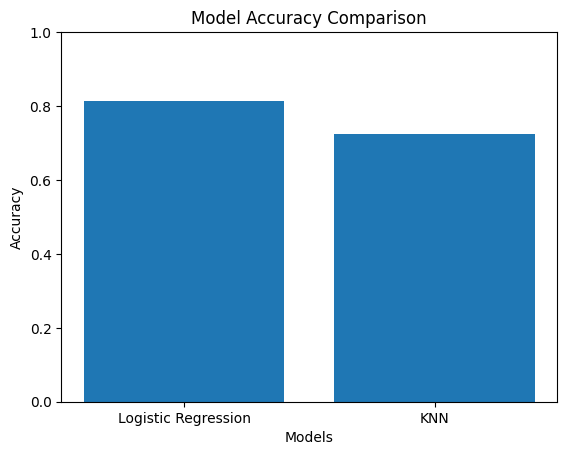

In [77]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Existing prints
lr_acc = accuracy_score(y_test, lr_pred)
knn_acc = accuracy_score(y_test, knn_pred)

print("Logistic Regression Accuracy:", lr_acc)
print(classification_report(y_test, lr_pred))

print("KNN Accuracy:", knn_acc)
print(classification_report(y_test, knn_pred))

# =========================
# GRAPH (ADD THIS PART)
# =========================
models = ['Logistic Regression', 'KNN']
accuracies = [lr_acc, knn_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)   # keeps scale clean (0 to 100%)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


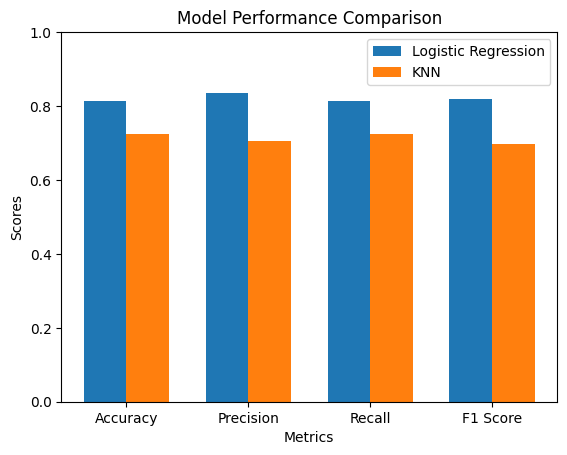

In [86]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import numpy as np

# Logistic metrics
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred, average='weighted')
lr_recall = recall_score(y_test, lr_pred, average='weighted')
lr_f1 = f1_score(y_test, lr_pred, average='weighted')

# KNN metrics
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_precision = precision_score(y_test, knn_pred, average='weighted')
knn_recall = recall_score(y_test, knn_pred, average='weighted')
knn_f1 = f1_score(y_test, knn_pred, average='weighted')

# Data for plotting
labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

lr_scores = [lr_accuracy, lr_precision, lr_recall, lr_f1]
knn_scores = [knn_accuracy, knn_precision, knn_recall, knn_f1]

x = np.arange(len(labels))
width = 0.35

# Plot
plt.figure()
plt.bar(x - width/2, lr_scores, width, label='Logistic Regression')
plt.bar(x + width/2, knn_scores, width, label='KNN')

plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x, labels)
plt.ylim(0, 1)
plt.legend()

plt.show()

**Sentiment Comparison**

In [78]:
pd.crosstab(df['TextBlob_Sentiment'], df['VADER_Sentiment'])

VADER_Sentiment,Negative,Neutral,Positive
TextBlob_Sentiment,,,
Negative,898,4,189
Neutral,10,0,7
Positive,620,5,1968


**Sentiment Percentage Chart**

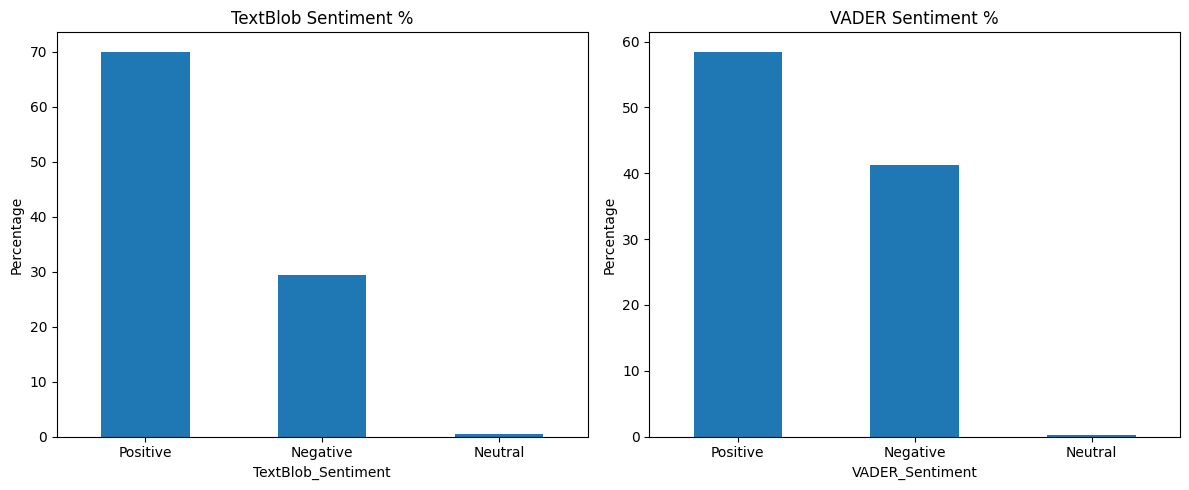

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# TextBlob
textblob_counts = df['TextBlob_Sentiment'].value_counts(normalize=True) * 100
textblob_counts.plot(kind='bar', ax=axes[0])
axes[0].set_title("TextBlob Sentiment %")

# VADER
vader_counts = df['VADER_Sentiment'].value_counts(normalize=True) * 100
vader_counts.plot(kind='bar', ax=axes[1])
axes[1].set_title("VADER Sentiment %")

for ax in axes:
    ax.set_ylabel("Percentage")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

**Ratings vs Sentiment**

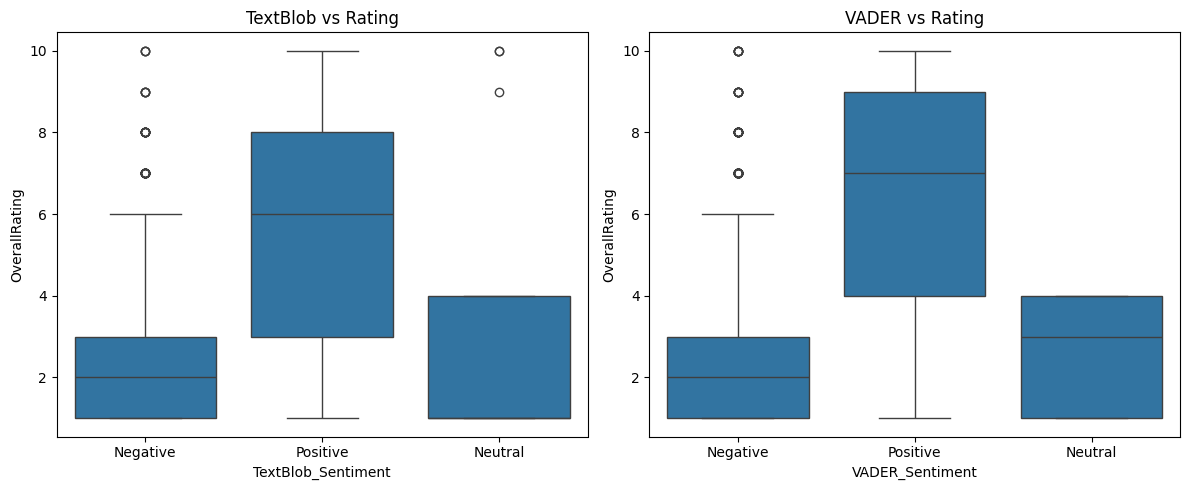

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# TextBlob
sns.boxplot(x='TextBlob_Sentiment', y='OverallRating', data=df, ax=axes[0])
axes[0].set_title("TextBlob vs Rating")

# VADER
sns.boxplot(x='VADER_Sentiment', y='OverallRating', data=df, ax=axes[1])
axes[1].set_title("VADER vs Rating")

plt.tight_layout()
plt.show()

**Heatmap Correlation**

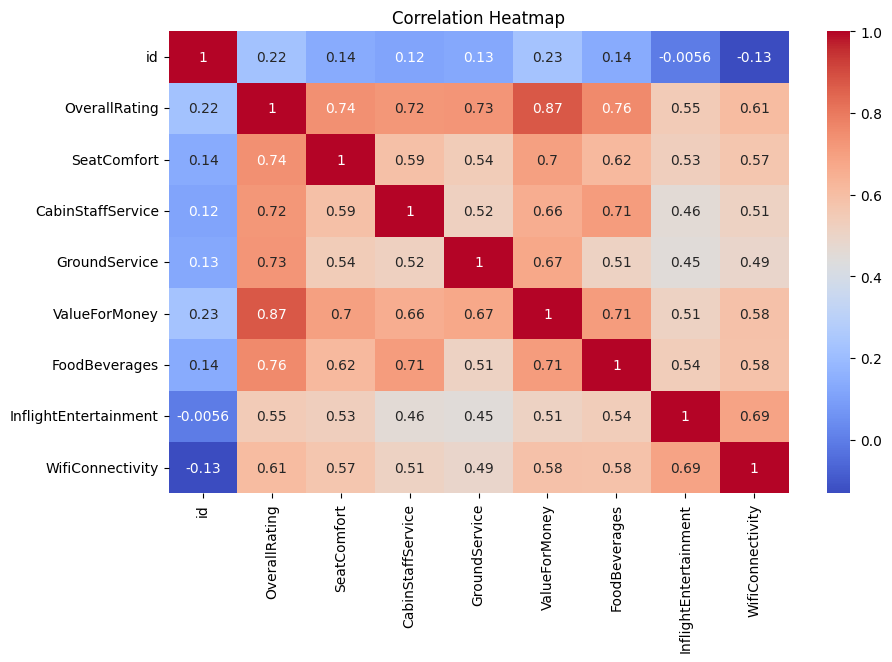

In [81]:
numeric_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

**Sentiment Comparison Bar**

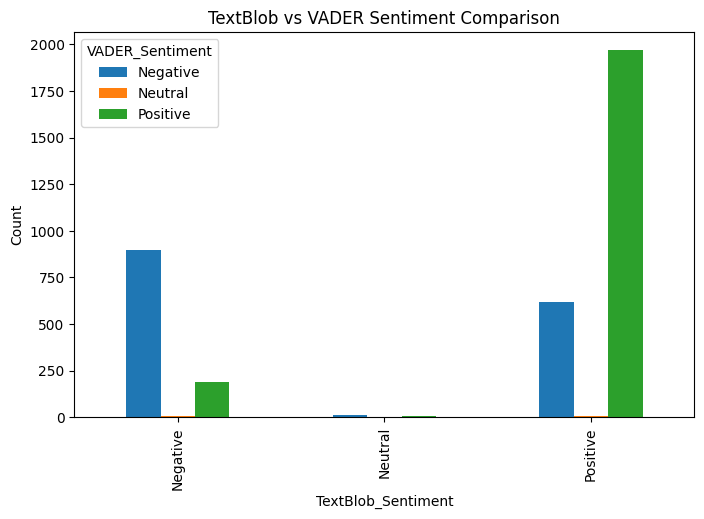

In [82]:
comparison = pd.crosstab(df['TextBlob_Sentiment'], df['VADER_Sentiment'])

comparison.plot(kind='bar', figsize=(8,5))
plt.title("TextBlob vs VADER Sentiment Comparison")
plt.ylabel("Count")
plt.show()

**Review Length Analysis**

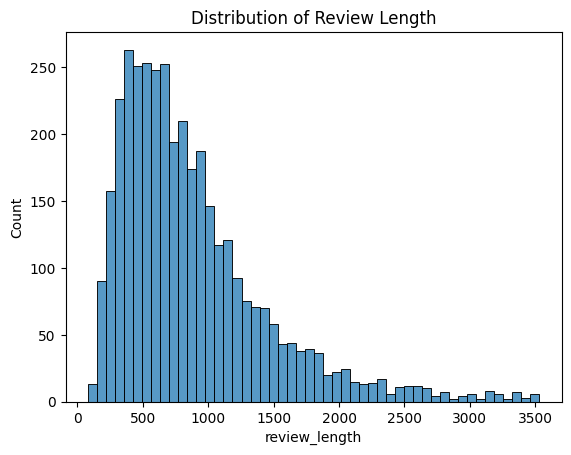

In [83]:
df['review_length'] = df['ReviewBody'].apply(lambda x: len(str(x)))

sns.histplot(df['review_length'], bins=50)
plt.title("Distribution of Review Length")
plt.show()

**Sentiment vs Review Length**

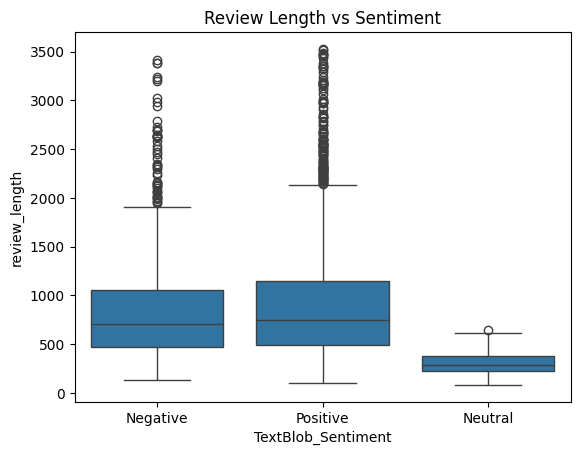

In [84]:
sns.boxplot(x='TextBlob_Sentiment', y='review_length', data=df)
plt.title("Review Length vs Sentiment")
plt.show()

**Top Words per Sentiment**

In [85]:
from collections import Counter

positive_words = " ".join(df[df['TextBlob_Sentiment']=='Positive']['ReviewBody'])
negative_words = " ".join(df[df['TextBlob_Sentiment']=='Negative']['ReviewBody'])

pos_common = Counter(positive_words.split()).most_common(10)
neg_common = Counter(negative_words.split()).most_common(10)

print("Top Positive Words:", pos_common)
print("Top Negative Words:", neg_common)

Top Positive Words: [('the', 17952), ('to', 13561), ('and', 13298), ('a', 9695), ('was', 9452), ('I', 7454), ('of', 6085), ('in', 5677), ('on', 5448), ('for', 4266)]
Top Negative Words: [('the', 6955), ('to', 5981), ('and', 4769), ('was', 3416), ('a', 3362), ('I', 3176), ('of', 2359), ('in', 2210), ('for', 1820), ('on', 1793)]
